# **CNN**

---
## 0. 환경 준비

In [ ]:
# 구글 드라이브와 연동
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
from pathlib import Path
import os
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from PIL import Image
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms


In [ ]:
torch.cuda.is_available() # GPU 사용 가능한지 체크

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('PyTorch', torch.__version__, '| Device:', device)

---
## 1. 이미지 로드
```

In [ ]:
dataset_dir = '' ## 경로 복사

In [ ]:
img_dir = os.path.join(dataset_dir,'animal.jpg')

In [ ]:
from PIL import Image
Image.open(img_dir)

In [ ]:
pil_img = Image.open(img_dir)
arr = np.array(pil_img)

In [ ]:
arr.shape

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(arr, cmap='gray')
#axes[0].axis('off')

crop = arr[420:430,420:430]
axes[1].imshow(crop)
for i in range(crop.shape[0]):
    for j in range(crop.shape[1]):
        axes[1].text(j, i, str(crop[i, j]), ha='center', va='center', fontsize=7, color='yellow')
plt.tight_layout()
plt.show()

In [ ]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
# 1) transform (MNIST는 원래 28x28 grayscale)

transform = transforms.Compose([
    transforms.ToTensor(),                          # [0,1] 텐서, shape (1,28,28)
])

# 2) dataset — download=True면 최초 1회 자동 다운로드
train_ds = datasets.MNIST(root='./data', train=True,  download=True, transform=transform)
test_ds  = datasets.MNIST(root='./data', train=False, download=True, transform=transform)


# 3) DataLoader
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=64, shuffle=False)

# 확인
x, y = next(iter(train_loader))
print(x.shape)   # torch.Size([64, 1, 28, 28])
print(y.shape)   # torch.Size([64])
print(y[:10])    # 레이블 0~9

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(10, 10))
for i in range(3):
    for j in range(3):
      x, y = train_ds[i*3+j]
      axes[i, j].imshow(x[0].squeeze(), cmap='gray')
      axes[i, j].set_title(y)

---
## 2. CNN model 생성

> **합성곱(Conv)**

# Convolutional Neural Network, CNN
* convolution
* ReLU
* pooling


![alt text](https://mukulrathi.com/aad8a78e265cb76c3b0ebe17a058b19c/conv-slide.gif)
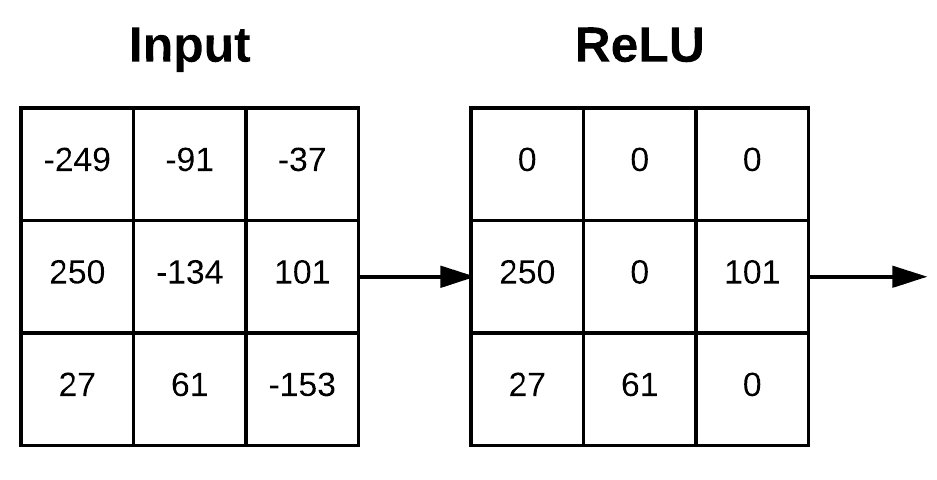
![alt text](https://nico-curti.github.io/NumPyNet/NumPyNet/images/maxpool.gif)

In [ ]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), 
            nn.ReLU(), 
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), 
            nn.ReLU(), 
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), 
            nn.ReLU(), 
            nn.AdaptiveAvgPool2d(1),
        )
        self.classifier = nn.Sequential(nn.Linear(64, num_classes),
                                        nn.Softmax(dim=-1))
    def forward(self, x):
        x = self.features(x)
        return self.classifier(x.view(x.size(0), -1))


In [ ]:
model = SimpleCNN(10)

In [ ]:
logit = model(x.unsqueeze(0))

In [ ]:
prob = nn.Softmax(dim=-1)(logit)

## 모델 학습 (Train)

In [ ]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total = 0.0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        loss = criterion(model(x), y)
        loss.backward()
        optimizer.step()
        total += loss.item() * x.size(0)
    return total / len(loader.dataset)



cnn = SimpleCNN().to(device)
cnn

In [ ]:
logit = cnn(x.unsqueeze(0).to(device))
prob = nn.Softmax(dim=-1)(logit)

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(cnn.parameters(), lr=1e-3)

for ep in range(1, 10):
    loss = train_one_epoch(cnn, train_loader, criterion, optimizer, device)
    if ep % 1 == 0:
        print(f'Epoch {ep:02d} loss={loss:.4f}')

In [ ]:
logit = cnn(x.unsqueeze(0).to(device))
prob = nn.Softmax(dim=-1)(logit)

In [ ]:
for ep in range(1, 10):
    loss = train_one_epoch(cnn, train_loader, criterion, optimizer, device)
    if ep % 1 == 0:
        print(f'Epoch {ep:02d} loss={loss:.4f}')

In [ ]:
logit = cnn(x.unsqueeze(0).to(device))
prob = nn.Softmax(dim=-1)(logit)

## 모델 검증

In [ ]:
@torch.no_grad()
def evaluate_cls(model, loader, device):
    model.eval()
    preds, targets = [], []
    for x, y in loader:
        preds.extend(model(x.to(device)).argmax(1).cpu().tolist())
        targets.extend(y.tolist())
    acc = accuracy_score(targets, preds)
    f1 = f1_score(targets, preds, average='macro')
    cm = confusion_matrix(targets, preds)
    return acc, f1, cm

In [ ]:
CLASS_NAMES = [f'{i}'for i in range(10)]
acc, f1, cm = evaluate_cls(cnn, test_loader, device)
print(f'Accuracy={acc:.3f} F1={f1:.3f}')
plt.imshow(cm, cmap='Blues')
plt.xticks(range(10), CLASS_NAMES); plt.yticks(range(10), CLASS_NAMES)
plt.xlabel('Predicted'); plt.ylabel('True')
for i in range(10):
    for j in range(10):
        plt.text(j, i, cm[i, j], ha='center', va='center')
plt.title('CNN Confusion Matrix')
plt.show()

## 웨이퍼맵 Defect 분류

In [ ]:
WAFER_DIR = os.path.join(dataset_dir, 'Wafermap')
CLASS_NAMES = ['Donut', 'Scratch']

for cls in CLASS_NAMES:
    print(f'{cls}: {len(list(Path(os.path.join(WAFER_DIR, cls)).glob("*.jpg")))}장')

In [ ]:
img_path = next(Path(os.path.join(WAFER_DIR,'Scratch')).glob('*.jpg'))

In [ ]:
pil_img = Image.open(img_path).convert('L')

In [ ]:
arr = np.array(pil_img)

In [ ]:
print('shape:', arr.shape, '| dtype:', arr.dtype)
print('범위:', arr.min(), '~', arr.max())

In [ ]:
crop = arr[25:35,50:60]
print(crop)

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(arr, cmap='gray')

axes[1].imshow(crop, cmap='gray')
for i in range(crop.shape[0]):
    for j in range(crop.shape[1]):
        axes[1].text(j, i, str(crop[i, j]), ha='center', va='center', fontsize=7, color='yellow')
plt.tight_layout()
plt.show()


In [ ]:
IMG_SIZE, BATCH_SIZE = 64, 16

train_tf = transforms.Compose([
    transforms.Grayscale(1), transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(), transforms.RandomVerticalFlip(),
    transforms.ToTensor(), transforms.Normalize([0.5], [0.5]),
])

eval_tf = transforms.Compose([
    transforms.Grayscale(1), transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(), transforms.Normalize([0.5], [0.5]),
])

full_ds = datasets.ImageFolder(WAFER_DIR, transform=eval_tf)
labels_all = [y for _, y in full_ds.samples]
train_idx, val_idx = train_test_split(list(range(len(full_ds))), test_size=0.2,
                                      stratify=labels_all, random_state=42)

In [ ]:
train_loader = DataLoader(Subset(datasets.ImageFolder(WAFER_DIR, train_tf), train_idx),
                          batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(Subset(datasets.ImageFolder(WAFER_DIR, eval_tf), val_idx),
                        batch_size=BATCH_SIZE)
class_to_idx = full_ds.class_to_idx
print('class_to_idx:', class_to_idx)

In [ ]:
for sample in train_loader:
    break

In [ ]:
x,y = sample

In [ ]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), 
            nn.ReLU(), 
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), 
            nn.ReLU(), 
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), 
            nn.ReLU(), 
            nn.AdaptiveAvgPool2d(1),
        )
        self.classifier = nn.Linear(64, num_classes)
    def forward(self, x):
        x = self.features(x)
        return self.classifier(x.view(x.size(0), -1))

In [ ]:
cnn = SimpleCNN(2)

In [ ]:
logits = model(x)

In [ ]:
probs = nn.Softmax(dim=-1)(logits)

In [ ]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total = 0.0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        loss = criterion(model(x), y)
        loss.backward()
        optimizer.step()
        total += loss.item() * x.size(0)
    return total / len(loader.dataset)

@torch.no_grad()
def evaluate_cls(model, loader, device):
    model.eval()
    preds, targets = [], []
    for x, y in loader:
        preds.extend(model(x.to(device)).argmax(1).cpu().tolist())
        targets.extend(y.tolist())
    acc = accuracy_score(targets, preds)
    f1 = f1_score(targets, preds, average='macro')
    cm = confusion_matrix(targets, preds)
    return acc, f1, cm

cnn = SimpleCNN().to(device)
cnn

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(cnn.parameters(), lr=1e-3)

for ep in range(1, 20):
    loss = train_one_epoch(cnn, train_loader, criterion, optimizer, device)
    acc, _, _ = evaluate_cls(cnn, val_loader, device)
    if ep % 1 == 0:
        print(f'Epoch {ep:02d} loss={loss:.4f} val_acc={acc:.3f}')

In [ ]:
acc, f1, cm = evaluate_cls(cnn, val_loader, device)
print(f'Accuracy={acc:.3f} F1={f1:.3f}')
plt.imshow(cm, cmap='Blues')
plt.xticks(range(2), CLASS_NAMES); plt.yticks(range(2), CLASS_NAMES)
plt.xlabel('Predicted'); plt.ylabel('True')
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha='center', va='center')
plt.title('CNN Confusion Matrix')
plt.show()